Input: document.jpg
Output: document_scanner
Pipeline: 
1. Read image →
2. grayscale →
3. blur →
4. edges →
5. contours →
6. page detection →
7. perspective correction →
8. CLAHE →
9. adaptive threshold →
10. morphology.


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

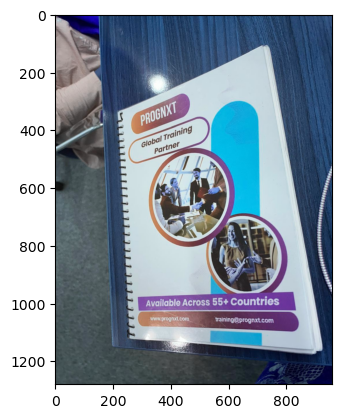

In [2]:
# 1
img = cv2.imread("img_scan.jpeg")
if img is None:
    raise FileNotFoundError("img_scan.jpeg")
plt.imshow(img)

In [3]:
# 2
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [4]:
# 3
blur = cv2.GaussianBlur(gray, (5, 5), 0)

In [5]:
# 4
edges = cv2.Canny(blur, 50, 150)
edges = cv2.dilate(edges, np.ones((3,3), np.uint8), iterations=1)

In [6]:
# 5
contours, _ = cv2.findContours(edges, cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
contours = sorted(contours, key=cv2.contourArea, reverse=True)


In [7]:
# 6, 7
page = None
for c in contours[:20]:
    peri = cv2.arcLength(c, True)
    approx = cv2.approxPolyDP(c, 0.02 * peri, True)
    if len(approx) == 4:
        page = approx.reshape(4,2).astype(np.float32)
        break

scan = img
if page is not None:
    s = page.sum(axis=1)
    d = np.diff(page, axis=1).ravel()
    rect = np.array([
        page[np.argmin(s)], page[np.argmin(d)],
        page[np.argmax(s)], page[np.argmax(d)]], dtype=np.float32)

    tl,tr,br,bl = rect
    W = int(max(np.linalg.norm(br-bl), np.linalg.norm(tr-tl)))
    H = int(max(np.linalg.norm(tr-br), np.linalg.norm(tl-bl)))
    dst = np.float32([[0,0],[W-1,0],[W-1,H-1],[0,H-1]])
    M = cv2.getPerspectiveTransform(rect, dst)
    scan = cv2.warpPerspective(img, M, (W,H))


In [8]:
# 8
g = cv2.cvtColor(scan, cv2.COLOR_BGR2GRAY)
g = cv2.createCLAHE(2.0, (8,8)).apply(g)
g = cv2.GaussianBlur(g, (3,3), 0)


In [21]:
# 9
ocr_ready = cv2.adaptiveThreshold(
    g, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY, 31, 10
)

In [22]:
# 10
ocr_ready = cv2.morphologyEx(
    ocr_ready, cv2.MORPH_OPEN, np.ones((2,2),np.uint8)
)


Done.


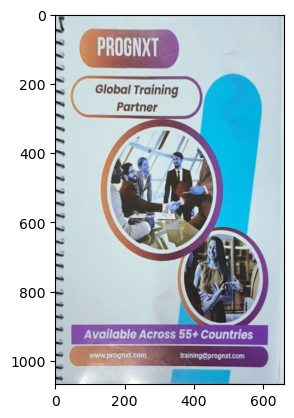

In [23]:
# output
cv2.imwrite("outputs_document_original.jpg", img)
cv2.imwrite("outputs_document_scan.jpg", scan)
cv2.imwrite("outputs_document_ocr_ready.png", ocr_ready)
print("Done.")
out = cv2.imread('outputs_document_scan.jpg')
plt.imshow(out)